## Mount Google Drive

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Create the Project Root Folder

In [91]:
import os

PROJECT_PATH = "/content/drive/MyDrive/sdg-loop-distribution"

os.makedirs(PROJECT_PATH, exist_ok=True)

print("Project folder created:", PROJECT_PATH)

Project folder created: /content/drive/MyDrive/sdg-loop-distribution


## Create the Project Structure

In [92]:
import os

PROJECT_PATH = "/content/drive/MyDrive/sdg-loop-distribution"

folders = [
    "input",
    "src",
    "visualize",
    "output",
    "output/graphs",
    "output/loops",
    "notebooks"
]

for f in folders:
    os.makedirs(f"{PROJECT_PATH}/{f}", exist_ok=True)

print("Folder structure created")

Folder structure created


## Install Required Libraries

In [93]:
!pip install networkx matplotlib

## Create Input File

In [94]:
loop_code = """S1: A[i] = B[i] + C[i]
S2: B[i] = A[i-1] + D[i]
S3: C[i] = B[i] + E[i]
S4: D[i] = C[i-1] + A[i]
"""

with open(f"{PROJECT_PATH}/input/example_loop.txt","w") as f:
    f.write(loop_code)

print("example_loop.txt created")

example_loop.txt created


## Create Parser File

In [95]:
parser_code = '''
import re

def parse_index(expr):

    pattern = r'([A-Za-z]+)\\[i([+-]\\d+)?\\]'
    match = re.match(pattern, expr.strip())

    if not match:
        return None

    array = match.group(1)
    offset = match.group(2)

    if offset is None:
        offset = 0
    else:
        offset = int(offset)

    return (array, offset)


def parse_statement(line):

    label, stmt = line.split(":")
    lhs, rhs = stmt.split("=")

    lhs = lhs.strip()
    rhs = rhs.strip()

    writes = []
    reads = []

    w = parse_index(lhs)

    if w:
        writes.append(w)

    tokens = re.findall(r"[A-Za-z]+\\[i[+-]?\\d*\\]", rhs)

    for t in tokens:
        r = parse_index(t)
        if r:
            reads.append(r)

    return {
        "label": label.strip(),
        "writes": writes,
        "reads": reads
    }


def parse_file(filepath):

    program = []

    with open(filepath) as f:
        for line in f:
            if line.strip():
                program.append(parse_statement(line))

    return program
'''

with open(f"{PROJECT_PATH}/src/parser.py","w") as f:
    f.write(parser_code)

print("parser.py created")

parser.py created


## Create RDG Builder File

In [96]:
rdg_code = '''
import networkx as nx

def direction(d):

    if d > 0:
        return "<"
    elif d < 0:
        return ">"
    else:
        return "="


def build_rdg(program):

    G = nx.DiGraph()

    for stmt in program:
        G.add_node(stmt["label"], data=stmt)

    for s1 in program:
        for s2 in program:

            if s1["label"] == s2["label"]:
                continue

            for w_array, w_off in s1["writes"]:

                for r_array, r_off in s2["reads"]:

                    if w_array == r_array:

                        d = r_off - w_off

                        G.add_edge(
                            s1["label"],
                            s2["label"],
                            type="RAW",
                            array=w_array,
                            distance=d,
                            direction=direction(d),
                            loop_carried=(d != 0)
                        )

                for w2_array, w2_off in s2["writes"]:

                    if w_array == w2_array:

                        d = w2_off - w_off

                        G.add_edge(
                            s1["label"],
                            s2["label"],
                            type="WAW",
                            array=w_array,
                            distance=d,
                            direction=direction(d),
                            loop_carried=(d != 0)
                        )

            for r_array, r_off in s1["reads"]:

                for w_array, w_off in s2["writes"]:

                    if r_array == w_array:

                        d = w_off - r_off

                        G.add_edge(
                            s1["label"],
                            s2["label"],
                            type="WAR",
                            array=r_array,
                            distance=d,
                            direction=direction(d),
                            loop_carried=(d != 0)
                        )

    return G
'''

with open(f"{PROJECT_PATH}/src/rdg_builder.py","w") as f:
    f.write(rdg_code)

print("rdg_builder.py created")

rdg_builder.py created


## Import the Project Modules

In [97]:
import sys
sys.path.append(PROJECT_PATH)

## Test Parser + RDG

In [98]:
from src.parser import parse_file
from src.rdg_builder import build_rdg

program = parse_file(f"{PROJECT_PATH}/input/example_loop.txt")

rdg = build_rdg(program)

for u,v,data in rdg.edges(data=True):
    print(u,"->",v,data)

S1 -> S2 {'type': 'WAR', 'array': 'B', 'distance': 0, 'direction': '=', 'loop_carried': False}
S1 -> S3 {'type': 'WAR', 'array': 'C', 'distance': 0, 'direction': '=', 'loop_carried': False}
S1 -> S4 {'type': 'RAW', 'array': 'A', 'distance': 0, 'direction': '=', 'loop_carried': False}
S2 -> S1 {'type': 'WAR', 'array': 'A', 'distance': 1, 'direction': '<', 'loop_carried': True}
S2 -> S3 {'type': 'RAW', 'array': 'B', 'distance': 0, 'direction': '=', 'loop_carried': False}
S2 -> S4 {'type': 'WAR', 'array': 'D', 'distance': 0, 'direction': '=', 'loop_carried': False}
S3 -> S1 {'type': 'RAW', 'array': 'C', 'distance': 0, 'direction': '=', 'loop_carried': False}
S3 -> S2 {'type': 'WAR', 'array': 'B', 'distance': 0, 'direction': '=', 'loop_carried': False}
S3 -> S4 {'type': 'RAW', 'array': 'C', 'distance': -1, 'direction': '>', 'loop_carried': True}
S4 -> S1 {'type': 'WAR', 'array': 'A', 'distance': 0, 'direction': '=', 'loop_carried': False}
S4 -> S2 {'type': 'RAW', 'array': 'D', 'distance': 

## Create SCC Module

In [99]:
scc_code = '''
import networkx as nx

def compute_scc(G):

    sccs = list(nx.strongly_connected_components(G))

    results = []

    for i, comp in enumerate(sccs):

        loop_carried = 0
        has_cycle = len(comp) > 1

        for u in comp:
            for v in comp:

                if G.has_edge(u, v):

                    if G[u][v]["loop_carried"]:
                        loop_carried += 1

        results.append({
            "id": f"SCC{i+1}",
            "nodes": list(comp),
            "size": len(comp),
            "has_cycle": has_cycle,
            "loop_carried_edges": loop_carried
        })

    return results
'''

with open(f"{PROJECT_PATH}/src/scc.py","w") as f:
    f.write(scc_code)

print("scc.py created")

scc.py created


## Create SDG Builder

In [100]:
sdg_code = '''
import networkx as nx

def build_sdg(rdg, sccs):

    SDG = nx.DiGraph()

    node_map = {}

    for scc in sccs:

        node_id = scc["id"]

        parallel = (scc["size"] == 1 and scc["loop_carried_edges"] == 0)

        SDG.add_node(
            node_id,
            statements=scc["nodes"],
            size=scc["size"],
            parallelizable=parallel,
            loop_carried_count=scc["loop_carried_edges"]
        )

        for stmt in scc["nodes"]:
            node_map[stmt] = node_id

    for u,v,data in rdg.edges(data=True):

        su = node_map[u]
        sv = node_map[v]

        if su != sv:
            SDG.add_edge(su, sv)

    return SDG
'''

with open(f"{PROJECT_PATH}/src/sdg_builder.py","w") as f:
    f.write(sdg_code)

print("sdg_builder.py created")

sdg_builder.py created


## Create Topological Walk Module

In [101]:
topo_code = '''
import networkx as nx

def topo_walk(SDG):

    order = list(nx.topological_sort(SDG))

    walk = []

    for node in order:

        data = SDG.nodes[node]

        action = "SPLIT" if data["parallelizable"] else "KEEP"

        walk.append((node, action, data["statements"]))

    return walk
'''

with open(f"{PROJECT_PATH}/src/topological_walk.py","w") as f:
    f.write(topo_code)

print("topological_walk.py created")

topological_walk.py created


## Create Loop Generator

In [127]:
import os

def generate_loops(walk, project_path, name="output"):

    loops = []

    for node, action, stmts in walk:

        if action == "SPLIT":
            code = "#pragma omp parallel for\n"
            code += "for(int i=0;i<N;i++){\n"
        else:
            code = "for(int i=0;i<N;i++){\n"

        for s in stmts:
            code += "   " + s + ";\n"

        code += "}\n\n"

        loops.append(code)

    final_code = "".join(loops)

    output_file = os.path.join(
        project_path,
        "output",
        "loops",
        f"{name}_distributed.c"
    )

    with open(output_file, "w") as f:
        f.write(final_code)

    print("Distributed loops saved to:", output_file)

    return final_code

# Code to write the function to a file
loop_generator_code = '''
import os

def generate_loops(walk, project_path, name="output"):

    loops = []

    for node, action, stmts in walk:

        if action == "SPLIT":
            code = "#pragma omp parallel for\\n"
            code += "for(int i=0;i<N;i++){\\n"
        else:
            code = "for(int i=0;i<N;i++){\\n"

        for s in stmts:
            code += "   " + s + ";\\n"

        code += "}\\n\\n"

        loops.append(code)

    final_code = "".join(loops)

    output_file = os.path.join(
        project_path,
        "output",
        "loops",
        f"{name}_distributed.c"
    )

    with open(output_file, "w") as f:
        f.write(final_code)

    print("Distributed loops saved to:", output_file)

    return final_code
'''

with open(f"{PROJECT_PATH}/src/loop_generator.py","w") as f:
    f.write(loop_generator_code)

print("src/loop_generator.py created")

src/loop_generator.py created


## Create RDG Visualization

In [138]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def draw_rdg(G, output_path, name="graph"):

    pos = nx.spring_layout(G)

    labels = {}
    edge_colors = []

    for u, v, data in G.edges(data=True):

        labels[(u, v)] = f"{data['type']} d={data['distance']}"

        if data["type"] == "RAW":
            edge_colors.append("red")
        elif data["type"] == "WAR":
            edge_colors.append("blue")
        else:
            edge_colors.append("green")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        edge_color=edge_colors,
        node_size=2000
    )

    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title("Reduced Dependence Graph (RDG)")

    save_path = os.path.join(
        output_path,
        "output",
        "graphs",
        f"{name}_rdg.png"
    )

    plt.savefig(save_path)
    plt.show()

    print("RDG saved at:", save_path)

# Code to write the function to a file
draw_rdg_code = '''
import matplotlib.pyplot as plt
import networkx as nx
import os

def draw_rdg(G, output_path, name="graph"):

    pos = nx.spring_layout(G)

    labels = {}
    edge_colors = []

    for u, v, data in G.edges(data=True):

        labels[(u, v)] = f"{data['type']} d={data['distance']}"

        if data["type"] == "RAW":
            edge_colors.append("red")
        elif data["type"] == "WAR":
            edge_colors.append("blue")
        else:
            edge_colors.append("green")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        edge_color=edge_colors,
        node_size=2000
    )

    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title("Reduced Dependence Graph (RDG)")

    save_path = os.path.join(
        output_path,
        "output",
        "graphs",
        f"{name}_rdg.png"
    )

    plt.savefig(save_path)
    plt.show()

    print("RDG saved at:", save_path)
'''

with open(f"{PROJECT_PATH}/visualize/draw_rdg.py","w") as f:
    f.write(draw_rdg_code)

print("visualize/draw_rdg.py created")

visualize/draw_rdg.py created


## Create SDG Visualization

In [147]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def draw_sdg(G, output_path, name="graph"):

    pos = nx.spring_layout(G)

    colors = []

    for node in G.nodes():

        if G.nodes[node]["parallelizable"]:
            colors.append("green")
        else:
            colors.append("red")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=colors,
        node_size=2500
    )

    plt.title("SCC Dependence Graph (SDG)")

    save_path = os.path.join(
        output_path,
        "output",
        "graphs",
        f"{name}_sdg.png"
    )

    plt.savefig(save_path)

    plt.show()

    print("SDG saved at:", save_path)

# Code to write the function to a file
draw_sdg_code = '''
import matplotlib.pyplot as plt
import networkx as nx
import os

def draw_sdg(G, output_path, name="graph"):

    pos = nx.spring_layout(G)

    colors = []

    for node in G.nodes():

        if G.nodes[node]["parallelizable"]:
            colors.append("green")
        else:
            colors.append("red")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=colors,
        node_size=2500
    )

    plt.title("SCC Dependence Graph (SDG)")

    save_path = os.path.join(
        output_path,
        "output",
        "graphs",
        f"{name}_sdg.png"
    )

    plt.savefig(save_path)

    plt.show()

    print("SDG saved at:", save_path)
'''

with open(f"{PROJECT_PATH}/visualize/draw_sdg.py","w") as f:
    f.write(draw_sdg_code)

print("visualize/draw_sdg.py created")

visualize/draw_sdg.py created


## Run the Full Pipeline

In [148]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def draw_rdg(G, output_path, name="graph"):

    pos = nx.spring_layout(G)

    labels = {}
    edge_colors = []

    for u, v, data in G.edges(data=True):

        labels[(u, v)] = f"{data['type']} d={data['distance']}"

        if data["type"] == "RAW":
            edge_colors.append("red")
        elif data["type"] == "WAR":
            edge_colors.append("blue")
        else:
            edge_colors.append("green")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        edge_color=edge_colors,
        node_size=2000
    )

    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title("Reduced Dependence Graph (RDG)")

    save_path = os.path.join(
        output_path,
        "output",
        "graphs",
        f"{name}_rdg.png"
    )

    plt.savefig(save_path)
    plt.show()

    print("RDG saved at:", save_path)

## Install Graphviz

In [149]:
!pip install graphviz
!apt-get install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


## Create Visualization File

In [150]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def draw_sdg(G, output_path, name="graph"):

    pos = nx.spring_layout(G)

    colors = []

    for node in G.nodes():

        if G.nodes[node]["parallelizable"]:
            colors.append("green")
        else:
            colors.append("red")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=colors,
        node_size=2500
    )

    plt.title("SCC Dependence Graph (SDG)")

    save_path = os.path.join(
        output_path,
        "output",
        "graphs",
        f"{name}_sdg.png"
    )

    plt.savefig(save_path)

    plt.show()

    print("SDG saved at:", save_path)

## Import in Notebook

In [151]:
from visualize.draw_sdg_paper_style import draw_sdg_paper_style

## Call the Function

In [152]:
draw_sdg_paper_style(sdg, PROJECT_PATH)

Paper-style SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/sdg_paper.png


## SDG Graph Exporter (JSON Format)

In [153]:
import json
import os

export_graph_code = '''
import json

def export_sdg_json(G, output_file):

    data = {
        "nodes": [],
        "edges": []
    }

    for node in G.nodes():

        node_data = {
            "id": node,
            "statements": G.nodes[node]["statements"],
            "size": G.nodes[node]["size"],
            "parallelizable": G.nodes[node]["parallelizable"],
            "loop_carried_count": G.nodes[node]["loop_carried_count"]
        }

        data["nodes"].append(node_data)

    for u, v in G.edges():

        edge_data = {
            "from": u,
            "to": v
        }

        data["edges"].append(edge_data)

    with open(output_file, "w") as f:
        json.dump(data, f, indent=4)

    print("SDG JSON exported to:", output_file)
'''

# Assuming PROJECT_PATH is defined in the kernel's global scope
with open(f"{PROJECT_PATH}/src/export_graph.py","w") as f:
    f.write(export_graph_code)

print("src/export_graph.py created")

def export_sdg_json(G, output_file):

    data = {
        "nodes": [],
        "edges": []
    }

    for node in G.nodes():

        node_data = {
            "id": node,
            "statements": G.nodes[node]["statements"],
            "size": G.nodes[node]["size"],
            "parallelizable": G.nodes[node]["parallelizable"],
            "loop_carried_count": G.nodes[node]["loop_carried_count"]
        }

        data["nodes"].append(node_data)

    for u, v in G.edges():

        edge_data = {
            "from": u,
            "to": v
        }

        data["edges"].append(edge_data)

    with open(output_file, "w") as f:
        json.dump(data, f, indent=4)

    print("SDG JSON exported to:", output_file)

src/export_graph.py created


## Main Function to run as Script


Running pipeline for: example_loop.txt



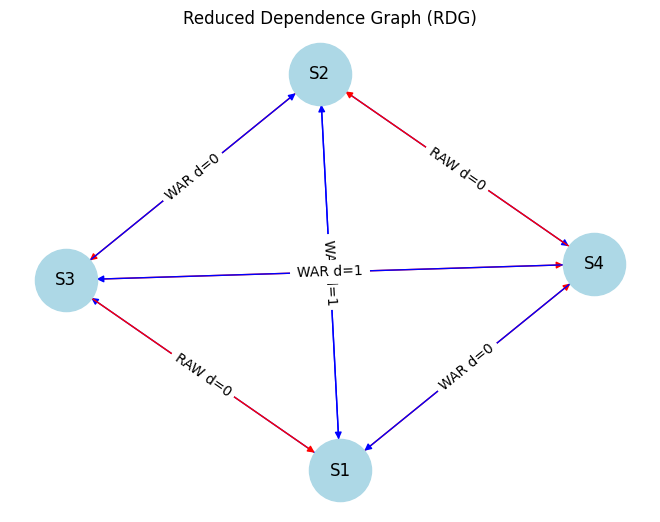

RDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/example_loop_rdg.png

SCC Results

{'id': 'SCC1', 'nodes': ['S4', 'S3', 'S1', 'S2'], 'size': 4, 'has_cycle': True, 'loop_carried_edges': 3}


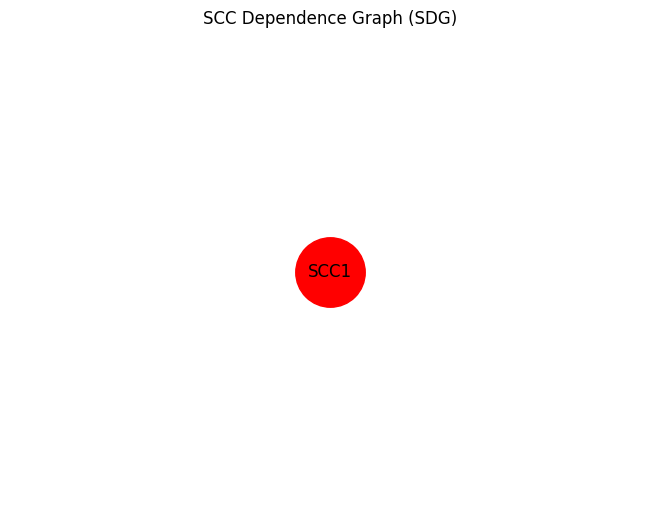

SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/example_loop_sdg.png
Paper-style SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/sdg_paper.png
SDG JSON exported to: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/example_loop_sdg.json

Topological Walk

('SCC1', 'KEEP', ['S4', 'S3', 'S1', 'S2'])
Distributed loops saved to: /content/drive/MyDrive/sdg-loop-distribution/output/loops/example_loop_distributed.c


In [154]:
import os
import sys
import importlib

# Correcting PROJECT_PATH to point to the established project root
PROJECT_PATH = "/content/drive/MyDrive/sdg-loop-distribution"

# Ensure project path is in sys.path
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

# Reload modules to ensure the latest versions are used
if 'src.parser' in sys.modules:
    importlib.reload(sys.modules['src.parser'])
if 'src.rdg_builder' in sys.modules:
    importlib.reload(sys.modules['src.rdg_builder'])
if 'src.scc' in sys.modules:
    importlib.reload(sys.modules['src.scc'])
if 'src.sdg_builder' in sys.modules:
    importlib.reload(sys.modules['src.sdg_builder'])
if 'src.topological_walk' in sys.modules:
    importlib.reload(sys.modules['src.topological_walk'])
if 'src.loop_generator' in sys.modules:
    importlib.reload(sys.modules['src.loop_generator'])
if 'src.export_graph' in sys.modules:
    importlib.reload(sys.modules['src.export_graph'])
if 'visualize.draw_rdg' in sys.modules:
    importlib.reload(sys.modules['visualize.draw_rdg'])
if 'visualize.draw_sdg' in sys.modules:
    importlib.reload(sys.modules['visualize.draw_sdg'])
if 'visualize.draw_sdg_paper_style' in sys.modules:
    importlib.reload(sys.modules['visualize.draw_sdg_paper_style'])

# Now import all modules
from src.parser import parse_file
from src.rdg_builder import build_rdg
from src.scc import compute_scc
from src.sdg_builder import build_sdg
from src.topological_walk import topo_walk
from src.loop_generator import generate_loops
from src.export_graph import export_sdg_json

from visualize.draw_rdg import draw_rdg
from visualize.draw_sdg import draw_sdg
from visualize.draw_sdg_paper_style import draw_sdg_paper_style


INPUT_FOLDER = os.path.join(PROJECT_PATH, "input")


def run_pipeline(input_file):

    name = input_file.replace(".txt","")

    print("\n=================================")
    print("Running pipeline for:", input_file)
    print("=================================\n")

    file_path = os.path.join(INPUT_FOLDER, input_file)

    program = parse_file(file_path)

    rdg = build_rdg(program)

    draw_rdg(rdg, PROJECT_PATH, name)

    sccs = compute_scc(rdg)

    print("\nSCC Results\n")

    for s in sccs:
        print(s)

    sdg = build_sdg(rdg, sccs)

    draw_sdg(sdg, PROJECT_PATH, name)

    draw_sdg_paper_style(sdg, PROJECT_PATH)

    export_sdg_json(
        sdg,
        os.path.join(
            PROJECT_PATH,
            "output",
            "graphs",
            f"{name}_sdg.json"
        )
    )

    walk = topo_walk(sdg)

    print("\nTopological Walk\n")

    for step in walk:
        print(step)

    generate_loops(walk, PROJECT_PATH, name)


def run_all_tests():

    files = os.listdir(INPUT_FOLDER)

    for f in files:

        if f.endswith(".txt"):
            run_pipeline(f)


if __name__ == "__main__":

    # In Colab, sys.argv often contains ['-f'] when run interactively.
    # This block now checks for that specific case to avoid misinterpreting '-f' as a filename.
    if len(sys.argv) > 1 and sys.argv[1] != '-f':
        run_pipeline(sys.argv[1])
    else:
        run_all_tests()

## Create Example Loops

In [155]:
def create_example_loops(input_folder):

    loops = {
        "example_loop.txt": """S1: A[i] = B[i] + C[i]
S2: B[i] = A[i-1] + D[i]
S3: C[i] = B[i] + E[i]
S4: D[i] = C[i-1] + A[i]
""",

        "loop_parallel.txt": """S1: A[i] = B[i] + C[i]
S2: D[i] = E[i] + F[i]
S3: G[i] = H[i] + I[i]
""",

        "loop_carried.txt": """S1: A[i] = A[i-1] + B[i]
S2: B[i] = C[i] + D[i]
""",

        "loop_mixed.txt": """S1: A[i] = B[i] + C[i]
S2: B[i] = A[i-1] + D[i]
S3: D[i] = E[i] + F[i]
""",

        "loop_complex.txt": """S1: X[i] = Y[i] + Z[i]
S2: Y[i] = X[i-1] + W[i]
S3: Z[i] = Y[i] + V[i]
S4: W[i] = Z[i-1] + X[i]
"""
    }

    for filename, content in loops.items():

        path = os.path.join(input_folder, filename)

        with open(path, "w") as f:
            f.write(content)

    print("Example loop files created in:", input_folder)

## Function Call

In [156]:
create_example_loops(INPUT_FOLDER)

Example loop files created in: /content/drive/MyDrive/sdg-loop-distribution/input


## Run Pipeline For All Test Cases


Running pipeline for: example_loop.txt



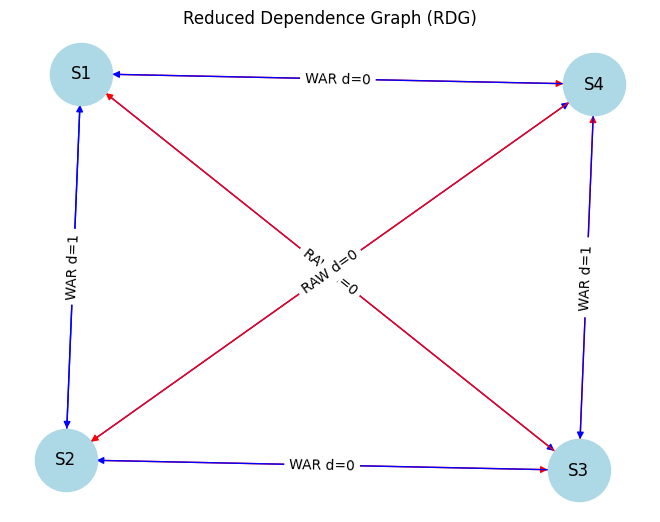

RDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/example_loop_rdg.png

SCC Results

{'id': 'SCC1', 'nodes': ['S4', 'S3', 'S1', 'S2'], 'size': 4, 'has_cycle': True, 'loop_carried_edges': 3}


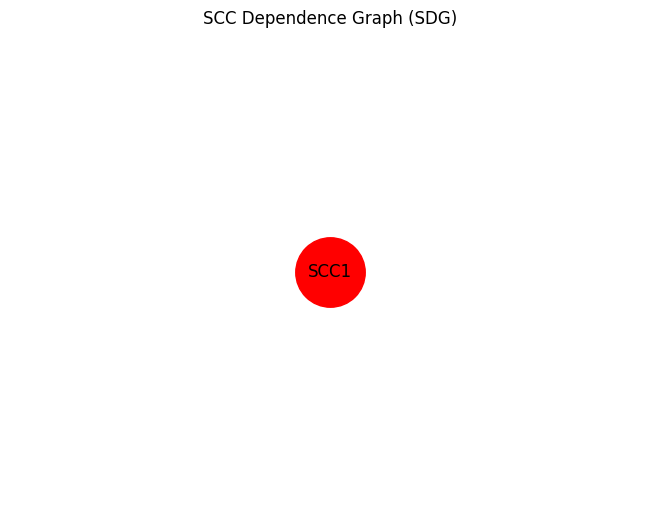

SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/example_loop_sdg.png
Paper-style SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/sdg_paper.png
SDG JSON exported to: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/example_loop_sdg.json

Topological Walk

('SCC1', 'KEEP', ['S4', 'S3', 'S1', 'S2'])
Distributed loops saved to: /content/drive/MyDrive/sdg-loop-distribution/output/loops/example_loop_distributed.c

Running pipeline for: loop_parallel.txt



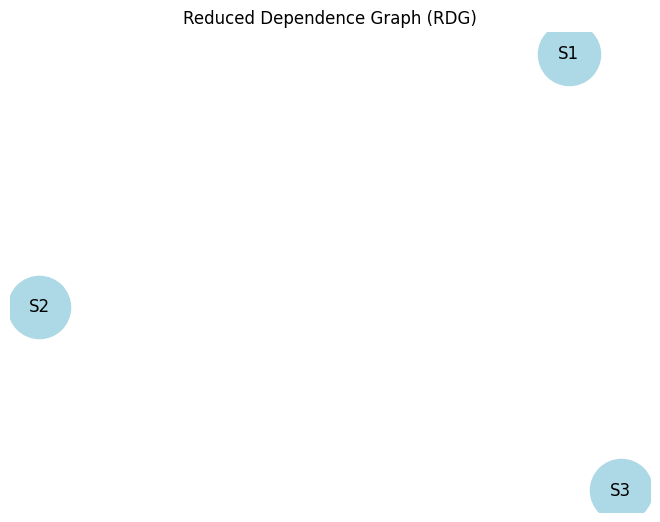

RDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_parallel_rdg.png

SCC Results

{'id': 'SCC1', 'nodes': ['S1'], 'size': 1, 'has_cycle': False, 'loop_carried_edges': 0}
{'id': 'SCC2', 'nodes': ['S2'], 'size': 1, 'has_cycle': False, 'loop_carried_edges': 0}
{'id': 'SCC3', 'nodes': ['S3'], 'size': 1, 'has_cycle': False, 'loop_carried_edges': 0}


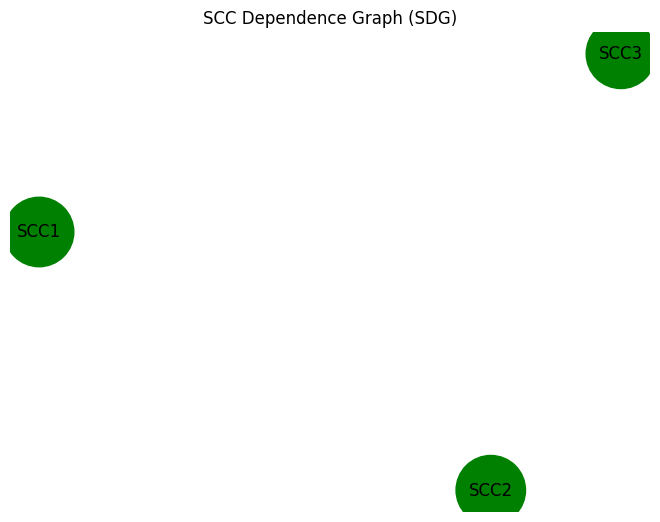

SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_parallel_sdg.png
Paper-style SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/sdg_paper.png
SDG JSON exported to: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_parallel_sdg.json

Topological Walk

('SCC1', 'SPLIT', ['S1'])
('SCC2', 'SPLIT', ['S2'])
('SCC3', 'SPLIT', ['S3'])
Distributed loops saved to: /content/drive/MyDrive/sdg-loop-distribution/output/loops/loop_parallel_distributed.c

Running pipeline for: loop_carried.txt



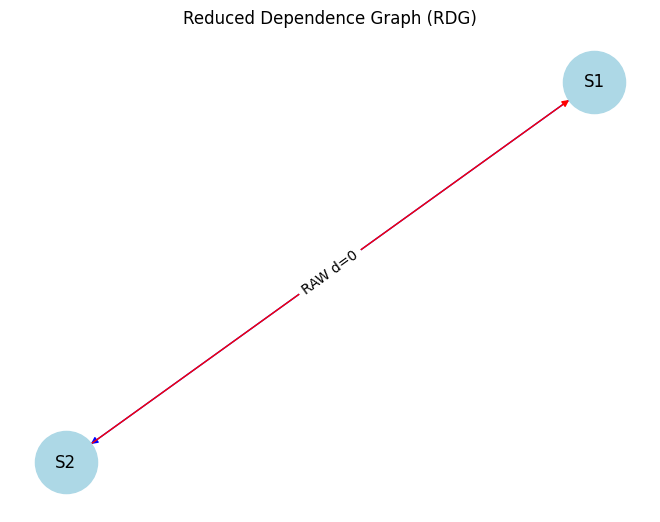

RDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_carried_rdg.png

SCC Results

{'id': 'SCC1', 'nodes': ['S1', 'S2'], 'size': 2, 'has_cycle': True, 'loop_carried_edges': 0}


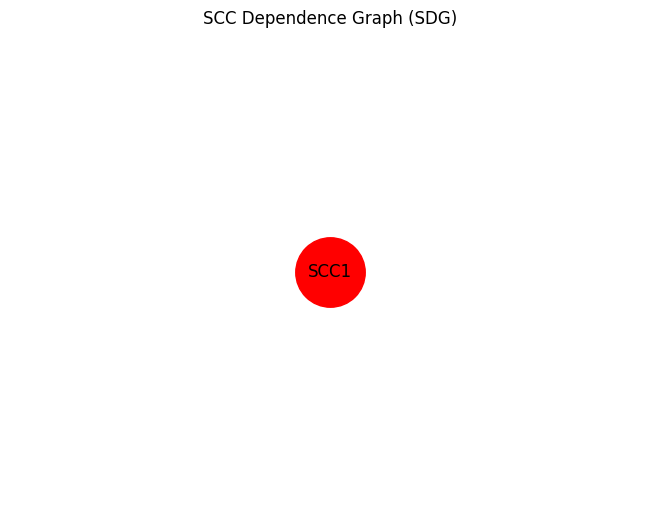

SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_carried_sdg.png
Paper-style SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/sdg_paper.png
SDG JSON exported to: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_carried_sdg.json

Topological Walk

('SCC1', 'KEEP', ['S1', 'S2'])
Distributed loops saved to: /content/drive/MyDrive/sdg-loop-distribution/output/loops/loop_carried_distributed.c

Running pipeline for: loop_mixed.txt



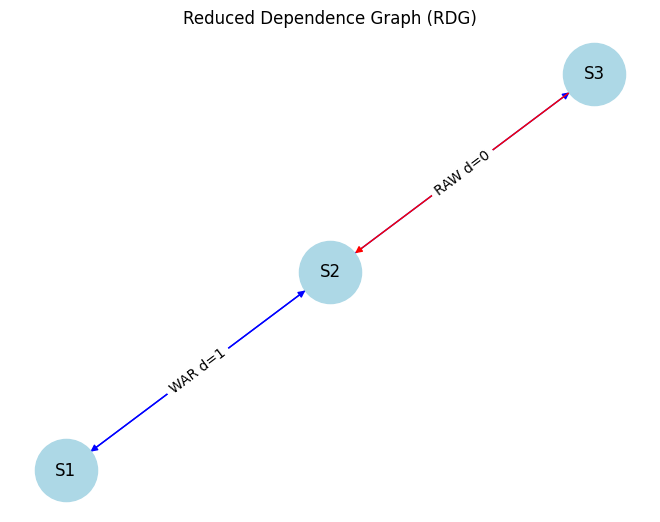

RDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_mixed_rdg.png

SCC Results

{'id': 'SCC1', 'nodes': ['S3', 'S1', 'S2'], 'size': 3, 'has_cycle': True, 'loop_carried_edges': 1}


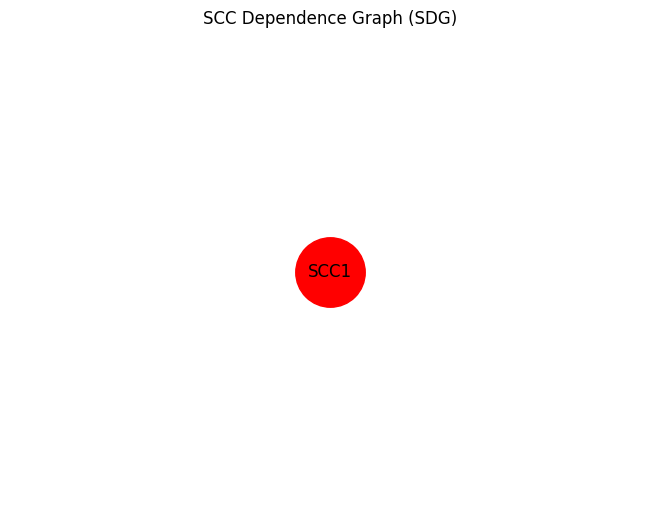

SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_mixed_sdg.png
Paper-style SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/sdg_paper.png
SDG JSON exported to: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_mixed_sdg.json

Topological Walk

('SCC1', 'KEEP', ['S3', 'S1', 'S2'])
Distributed loops saved to: /content/drive/MyDrive/sdg-loop-distribution/output/loops/loop_mixed_distributed.c

Running pipeline for: loop_complex.txt



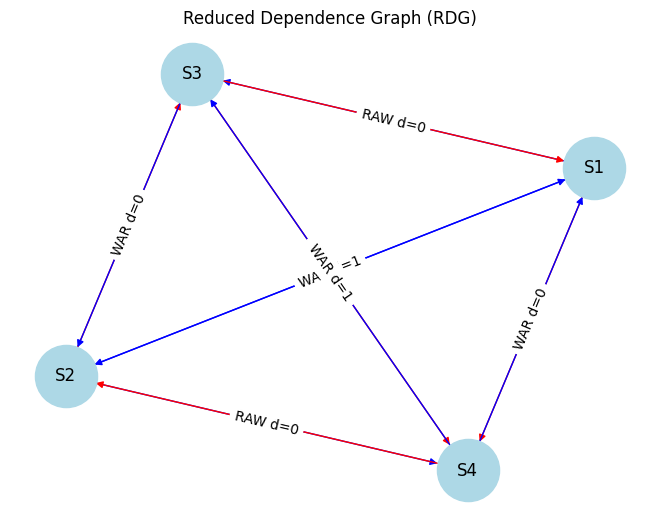

RDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_complex_rdg.png

SCC Results

{'id': 'SCC1', 'nodes': ['S4', 'S3', 'S1', 'S2'], 'size': 4, 'has_cycle': True, 'loop_carried_edges': 3}


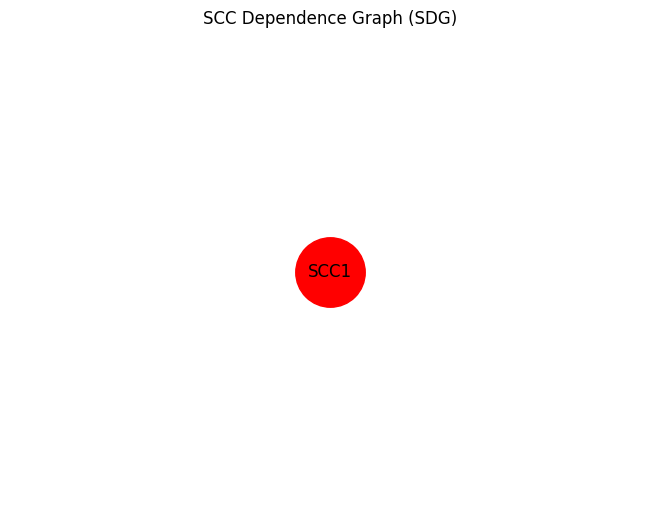

SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_complex_sdg.png
Paper-style SDG saved at: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/sdg_paper.png
SDG JSON exported to: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_complex_sdg.json

Topological Walk

('SCC1', 'KEEP', ['S4', 'S3', 'S1', 'S2'])
Distributed loops saved to: /content/drive/MyDrive/sdg-loop-distribution/output/loops/loop_complex_distributed.c


In [157]:
run_all_tests()